In [4]:
# models: clustering [kmeans, (with lda, svd), svm], neural networks w2v, logistic reg
# func eval_kmeans/svm (model, train,test) = acc, roc 
# def vectorize() = tfidf, counter, bow, embeddings
# pre processing -> vectorize/embeddings -> models 

In [ ]:
# imports
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split,KFold
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC

import os.path
import codecs

from preprocessing import preprocessing
from extraction_vocab_bow import basic_bow_exploration

from nltk.corpus import stopwords


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def load_movies(path2data):
    alltxts = [] # init vide
    labs = []
    cpt = 0
    for cl in os.listdir(path2data):
        for f in os.listdir(path2data+cl):
            txt = open(path2data+cl+'/'+f).read()
            alltxts.append(txt)
            labs.append(cpt)
        cpt+=1 
    return alltxts,labs

path = "./Dataset/movies1000/"
alltxts,alllabs = load_movies(path)

In [29]:
# preprocessing

def preprocess_texts(alltxts):
    return [preprocessing(text,word_norm='lemma') for text in alltxts]

cleaned_txts = preprocess_texts(alltxts)

In [30]:
print(len(cleaned_txts),len(alltxts))

2000 2000


In [31]:
cleaned_txts[0]

'    holy man    boast a sweet    gentle    comic performance from an unusually subdue eddie murphy and a few moderately funny skit     unfortunately    to get to the good stuff you have to sit through a painfully long set up    load of tedious filler    interminable shot of jeff goldblum stammer and twitch    a superfluous romantic subplot and quite possibly the most annoying performance of robert loggia s career     if ever a movie scream    wait for video so you can fast forward through all the dull and annoying part      this be it     eddie murphy play g    a rob nomadic pilgrim wander the land enjoy the moment and spread his spiritual message     a chance meeting with ricky hayman    goldblum      a stress out executive of a home shopping channel    and kate newell    kelly preston      a no nonsense medium analyst    result in physical injury to g    quick than you can say    the odd couple      g end up room with an extremely leery ricky     after some script gymnastic    g app

2000 documents
taille origine du vocab: 31181 mots total
['00' '000' '0009f' ... 'zwigoff' 'zycie' 'zzzzzzz'] 

vocab avec les 100 mots plus frequents :
['about' 'after' 'all' 'also' 'an' 'and' 'any' 'as' 'at' 'bad' 'be'
 'because' 'but' 'by' 'can' 'character' 'come' 'do' 'end' 'even' 'film'
 'find' 'first' 'for' 'from' 'get' 'give' 'go' 'good' 'have' 'he' 'her'
 'his' 'how' 'if' 'in' 'into' 'it' 'its' 'just' 'know' 'life' 'like'
 'look' 'make' 'man' 'more' 'most' 'movie' 'much' 'no' 'not' 'of' 'off'
 'on' 'one' 'only' 'or' 'other' 'out' 'play' 'plot' 'really' 'say' 'scene'
 'see' 'seem' 'she' 'so' 'some' 'story' 'take' 'than' 'that' 'the' 'their'
 'there' 'they' 'thing' 'this' 'time' 'to' 'too' 'two' 'up' 'very' 'way'
 'we' 'well' 'what' 'when' 'which' 'while' 'who' 'will' 'with' 'work'
 'would' 'year' 'you'] 

100 mots avec la plus grande frequence doc:
['the' 'be' 'of' 'and' 'to' 'in' 'it' 'that' 'with' 'for' 'have' 'as'
 'but' 'this' 'on' 'film' 'one' 'an' 'by' 'his' 'he' 'who' 'at

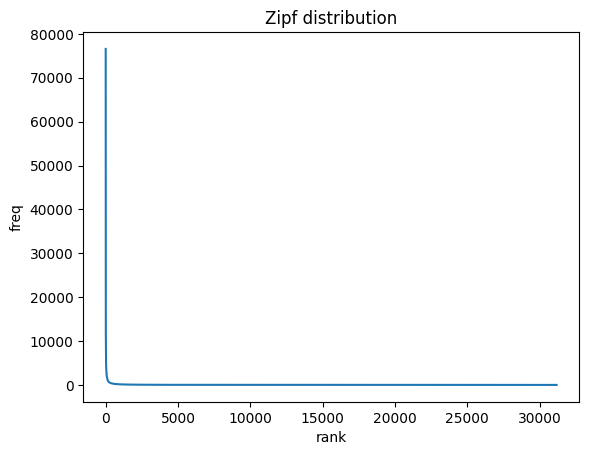

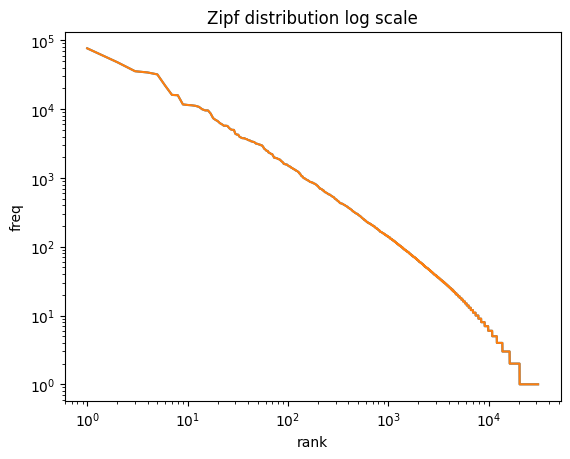


100 bigrammes les plus freq:
['about the' 'all of' 'all the' 'and be' 'and his' 'and it' 'and the'
 'as the' 'as well' 'at least' 'at the' 'be also' 'be an' 'be in'
 'be just' 'be more' 'be not' 'be one' 'be so' 'be that' 'be the' 'but it'
 'but the' 'by the' 'character be' 'do not' 'film be' 'for the' 'from the'
 'go to' 'have be' 'have the' 'have to' 'he be' 'he have' 'if you'
 'in his' 'in the' 'in this' 'into the' 'it be' 'kind of' 'lot of'
 'make the' 'more than' 'most of' 'movie be' 'of course' 'of his' 'of the'
 'of this' 'on the' 'one of' 'out of' 'play by' 'see the' 'seem to'
 'she be' 'some of' 'that be' 'that he' 'that it' 'that the'
 'the audience' 'the character' 'the end' 'the film' 'the first'
 'the good' 'the most' 'the movie' 'the only' 'the other' 'the plot'
 'the same' 'the story' 'the two' 'the way' 'the world' 'there be'
 'they be' 'this be' 'this film' 'this movie' 'to be' 'to do' 'to get'
 'to have' 'to make' 'to see' 'to the' 'try to' 'want to' 'when the'
 'whi

In [32]:
# bow vocab exploring
basic_bow_exploration(cleaned_txts)

**(b) Dictionary processing, restricting vocabulary size: corpus-specific stopwords** => max_df + suppress rare words (min_df) + max_features

- **max_df:** float in range [0.0, 1.0] or int, default=1.0
When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

- **min_df:** float in range [0.0, 1.0] or int, default=1
When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold. This value is also called cut-off in the literature. If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

- **max_features:** int or None, default=None
If not None, build a vocabulary that only consider the top max_features ordered by term frequency across the corpus.
This parameter is ignored if vocabulary is not None.

In [ ]:
# vectorization  

final_stopwords_list = stopwords.words('english') + stopwords.words('french')


def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=1, min_df=1):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(alltxts,vectorizer):
    X = vectorizer.fit_transform(alltxts)
    return X






In [34]:
count_vect = build_vectorizer(name="count")
countX = vectorize_txts(alltxts,count_vect)
X_train, X_test, y_train, y_test  = train_test_split(countX, alllabs, test_size=0.2, random_state=10, shuffle=True)

In [48]:
print(X_train.shape,X_test.shape,len(y_train),len(y_test))

(1600, 15303) (400, 15303) 1600 400


In [ ]:
## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 8, max_iter = 300,n_inits = 5,penalty='l2',loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter,n_inits = n_inits) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(penalty=penalty,solver=solver,max_iter=max_iter)

def train_model():
    pass

def eval_kmeans(model,train,test):
    """returns accuracy and roc"""
    pass

In [ ]:
def pipeline(model,data,test):
    model.fit(data)
    model.predict(test)